# Malicious URL Dataset: Acquisition, Understanding, Cleaning, EDA, and Statistical Reasoning

This notebook is structured as an analytical report demonstrating five core data science competencies:

1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Statistical Reasoning and Interpretation
4. Reproducibility 

Primary dataset reference: `https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset`

## Reproducibility Notes

- Expected project layout: notebook in `notebooks/` and CSV in `data/malicious_phish.csv`
- Run from either repository root or `notebooks/`
- Dependencies should be installed from `requirements.txt`
- This notebook does not install packages at runtime to keep execution deterministic

In [97]:
from pathlib import Path
from io import StringIO
from urllib.parse import urlsplit
import hashlib
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")
RANDOM_STATE = 42
EXPECTED_LABELS = ('benign', 'phishing', 'malware', 'defacement')


def draw_no_data(ax, title: str, message: str = 'No data available for this chart.') -> None:
    # Reuse one placeholder so every empty chart fails in a readable way.
    ax.clear()
    ax.set_title(title)
    ax.axis('off')
    ax.text(0.5, 0.5, message, ha='center', va='center', fontsize=10)


def safe_sample_frame(df: pd.DataFrame, n: int, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    # sample() raises if n is larger than the number of available rows.
    if df.empty or n <= 0:
        return df.iloc[0:0].copy()
    return df.sample(min(len(df), n), random_state=random_state)


def safe_display_sample(df: pd.DataFrame, n: int = 5, random_state: int = RANDOM_STATE) -> None:
    if df.empty:
        print('No rows available for sampling.')
        return
    display(safe_sample_frame(df, n=n, random_state=random_state))


def finalize_figure(fig=None) -> None:
    # Keep layout/show logic in one place so every chart is rendered consistently.
    if fig is None:
        fig = plt.gcf()
    fig.tight_layout()
    plt.show()



## 1. Data Acquisition

### Dataset source and origin
The dataset is the Kaggle **Malicious URLs Dataset** (`sid321axn/malicious-urls-dataset`).

The Kaggle description states the final dataset was assembled from multiple upstream sources (including ISCX-URL-2016( https://www.unb.ca/cic/datasets/url-2016.html University of New Brunswick), Malware Domain Blacklist, PhishTank, and PhishStorm) and merged into a two-column table: `url` and `type`.


In [98]:
KAGGLE_DATASET_URL = 'https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset'

source_summary = pd.DataFrame(
    {
        'source': [
            'ISCX-URL-2016',
            'Malware Domain Blacklist',
            'Faizan repository',
            'PhishTank',
            'PhishStorm',
        ],
        'noted_role': [
            'Base collection for benign/phishing/malware/defacement URLs',
            'Additional phishing and malware URLs',
            'Additional benign URLs',
            'Additional phishing URLs',
            'Additional phishing URLs',
        ],
    }
)

display(source_summary)
print(f'Dataset reference: {KAGGLE_DATASET_URL}')

,source,noted_role
0,ISCX-URL-2016,Base collection for benign/phishing/malware/defacement URLs
1,Malware Domain Blacklist,Additional phishing and malware URLs
2,Faizan repository,Additional benign URLs
3,PhishTank,Additional phishing URLs
4,PhishStorm,Additional phishing URLs


Dataset reference: https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset


In [99]:
def resolve_data_path() -> Path:
    # Support running the notebook either from the repo root or from notebooks/.
    candidate_paths = [
        Path('../data/malicious_phish.csv'),
        Path('data/malicious_phish.csv'),
    ]
    for path in candidate_paths:
        if path.exists():
            return path.resolve()

    checked = '\n'.join(str(p.resolve()) for p in candidate_paths)
    raise FileNotFoundError(f'Could not find malicious_phish.csv. Checked:\n{checked}')


def file_sha256(path: Path, chunk_size: int = 1 << 20) -> str:
    # Hash the file in chunks so large CSVs do not need to be read into memory at once.
    digest = hashlib.sha256()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()


def load_dataset(path: Path) -> pd.DataFrame:
    try:
        # Read all columns as strings first; feature engineering will cast later where needed.
        df = pd.read_csv(path, dtype='string', engine='python', on_bad_lines='skip')
    except Exception as exc:
        raise RuntimeError(f'Failed to load dataset from {path}: {exc}') from exc

    if df.empty:
        raise ValueError('Dataset loaded successfully but contains zero rows.')

    # Normalize column names so minor header differences do not break the notebook.
    normalized_cols = {str(c).strip().lower(): c for c in df.columns}

    if {'url', 'type'}.issubset(normalized_cols):
        out = df[[normalized_cols['url'], normalized_cols['type']]].copy()
        out.columns = ['url', 'type']
    elif {'password', 'strength'}.issubset(normalized_cols):
        out = df[[normalized_cols['password'], normalized_cols['strength']]].copy()
        out.columns = ['url', 'type']
        print("[info] Loaded password/strength schema and mapped it to ['url', 'type'] for notebook compatibility.")
    elif len(df.columns) >= 2:
        # Last-resort fallback: keep the notebook runnable even when headers are unexpected.
        out = df.iloc[:, :2].copy()
        out.columns = ['url', 'type']
        print("[info] Using the first two columns as ['url', 'type'] because expected column names were not found.")
    else:
        raise ValueError(f'Expected at least two columns, found: {list(df.columns)}')

    out['url'] = out['url'].astype('string')
    out['type'] = out['type'].astype('string')
    return out


data_path = resolve_data_path()
df_raw = load_dataset(data_path)

# Provenance fields make it easier to verify exactly which local file was analyzed.
provenance = {
    'data_path': str(data_path),
    'file_size_mb': round(data_path.stat().st_size / (1024 * 1024), 3),
    'sha256': file_sha256(data_path),
    'rows_loaded': len(df_raw),
    'columns_loaded': list(df_raw.columns),
}

print('Data provenance:')
for k, v in provenance.items():
    print(f'- {k}: {v}')



Data provenance:
- data_path: C:\Users\Nimish\Desktop\malicious-url-detection\data\malicious_phish.csv
- file_size_mb: 43.549
- sha256: d83ce942075dd63ed4d11560cfdcd9d512caa3d680e292f22cab484e8f074d01
- rows_loaded: 651191
- columns_loaded: ['url', 'type']


The loading logic is intentionally explicit: it validates expected columns, prints file provenance, and uses relative paths so that execution is reproducible across machines.

## 2. Data Understanding

### Dataset schema

| Column | Type | Meaning |
|---|---|---|
| `url` | string | Raw URL text |
| `type` | categorical string | Class label (`benign`, `phishing`, `malware`, `defacement`) |

### Label/class definitions
- `benign`: non-malicious URL
- `phishing`: deceptive URL used for credential/data theft
- `malware`: URL associated with malware delivery/hosting
- `defacement`: URL tied to compromised or altered web pages

In [100]:
print('Shape:', df_raw.shape)
print('Columns:', list(df_raw.columns))

print('\nSample rows:')
safe_display_sample(df_raw, n=5, random_state=RANDOM_STATE)

buf = StringIO()
df_raw.info(buf=buf)
print('\nDataFrame info:')
print(buf.getvalue())



Shape: (651191, 2)
Columns: ['url', 'type']

Sample rows:


,url,type
536448,http://37.49.226.178/deusbins/deus.sh4,malware
40630,medical-dictionary.thefreedictionary.com/Galt+trephine,benign
630496,www.jscape.com/sshfactory/,phishing
426724,http://www.wsnc.org.au/component/jcalpro/view/983,defacement
184034,virtualtourist.com/travel/North_America/Canada/Province_of_Quebec/Montreal-906413/Transportation-Montreal-Train-BR-2...,benign



DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     651191 non-null  string
 1   type    651191 non-null  string
dtypes: string(2)
memory usage: 9.9 MB



In [101]:
class_counts = df_raw['type'].value_counts(dropna=False)
class_props = (df_raw['type'].value_counts(normalize=True, dropna=False) * 100).round(2)

# Combine counts and percentages so class balance is easier to read in one table.
class_summary = pd.concat([
    class_counts.rename('count'),
    class_props.rename('percentage'),
], axis=1).sort_values('count', ascending=False)

display(class_summary)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Largest-to-smallest class ratio: {imbalance_ratio:.2f}:1")
print(f"Unique URLs: {df_raw['url'].nunique():,}")



,count,percentage
type,,
benign,428103,65.740
defacement,96457,14.810
phishing,94111,14.450
malware,32520,4.990


Largest-to-smallest class ratio: 13.16:1
Unique URLs: 641,119


In [102]:
understanding = df_raw.copy()
# Add quick exploratory columns without changing the original raw dataset.
understanding['url_length'] = understanding['url'].str.len()
understanding['has_scheme'] = understanding['url'].str.contains(r'^https?://', regex=True, case=False, na=False)

length_stats = (
    understanding.groupby('type')['url_length']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

scheme_stats = (
    understanding.groupby('type')['has_scheme']
    .mean()
    .mul(100)
    .round(2)
    .rename('pct_with_http_or_https')
    .to_frame()
)

print('URL length summary by class:')
display(length_stats)
print('Scheme usage by class (%):')
display(scheme_stats)



URL length summary by class:


,count,mean,median,std,min,max
type,,,,,,
defacement,96457,86.339,81.000,41.885,17,327
benign,428103,57.675,46.000,44.301,6,2175
malware,32520,56.543,49.000,28.441,7,378
phishing,94111,45.858,35.000,43.751,1,1779


Scheme usage by class (%):


,pct_with_http_or_https
type,
benign,8.260
defacement,100.000
malware,96.280
phishing,26.410


### Understanding highlights
- The dataset is multiclass and materially imbalanced, with `benign` dominant.
- URL lengths differ across classes, suggesting lexical structure can provide predictive signal.
- Explicit `http/https` prefixes are inconsistent, so downstream feature extraction should not assume scheme presence.

## 3. Data Cleaning

This cleaning pipeline is conservative and auditable. It removes clearly invalid or ambiguous records while preserving URL text as much as possible.

### Cleaning rules
1. Normalize basic string formatting (`strip`, lowercase labels)
2. Remove null/empty URL or label values
3. Keep only expected labels
4. Remove URLs with internal whitespace or control characters(ASCII or UNICODE \n \f etc)
5. Remove exact duplicate rows
6. Remove exact duplicate URLs with conflicting labels

In [103]:
LABEL_NORMALIZATION = {
    'benign': 'benign',
    'phishing': 'phishing',
    'malware': 'malware',
    'defacement': 'defacement',
    '0': 'class_0',
    '1': 'class_1',
    '2': 'class_2',
    '3': 'class_3',
}


def normalize_label(value) -> str:
    if pd.isna(value):
        return ''
    label = str(value).strip().lower()
    return LABEL_NORMALIZATION.get(label, label)


def run_cleaning_pipeline(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    work = df.copy()
    audit = []

    def record(step: str, before: int, after: int) -> None:
        removed = before - after
        audit.append(
            {
                'step': step,
                'rows_before': before,
                'rows_after': after,
                'rows_removed': removed,
                'pct_removed': round((removed / before) * 100, 4) if before else 0.0,
            }
        )

    before = len(work)
    work['url'] = work['url'].astype('string').str.strip()
    work['type'] = work['type'].map(normalize_label).astype('string')
    record('normalize formatting and labels', before, len(work))

    before = len(work)
    work = work[work['url'].notna() & work['type'].notna()]
    record('drop missing url/type', before, len(work))

    before = len(work)
    work = work[(work['url'].str.len() > 0) & (work['type'].str.len() > 0)]
    record('drop empty url/type after strip', before, len(work))

    before = len(work)
    # Restrict the analysis to the four labels documented for this notebook.
    work = work[work['type'].isin(EXPECTED_LABELS)]
    record('keep expected labels only', before, len(work))

    before = len(work)
    work = work[~work['url'].str.contains(r'\s', regex=True, na=False)]
    record('remove URLs containing whitespace', before, len(work))

    before = len(work)
    work = work[~work['url'].str.contains(r'[\x00-\x1f\x7f]', regex=True, na=False)]
    record('remove URLs containing control chars', before, len(work))

    before = len(work)
    work = work.drop_duplicates()
    record('remove exact duplicate rows', before, len(work))

    before = len(work)
    # If the exact same URL appears with multiple labels, drop it rather than guess.
    conflicting_urls = (
        work.groupby('url')['type']
        .nunique()
        .loc[lambda s: s > 1]
        .index
    )
    work = work[~work['url'].isin(conflicting_urls)]
    record('remove duplicate URLs with conflicting labels', before, len(work))

    work = work.reset_index(drop=True)
    audit_df = pd.DataFrame(audit)
    return work, audit_df


df_clean, cleaning_audit = run_cleaning_pipeline(df_raw)

if df_clean.empty:
    raise ValueError(
        'Cleaning produced an empty dataset after filtering invalid labels and malformed URLs. '
        'Check source data and preprocessing assumptions.'
    )

display(cleaning_audit)
print(f"Rows before cleaning: {len(df_raw):,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Rows removed total:   {len(df_raw) - len(df_clean):,}")

# Surface dropped label names so students can see how raw data differed from expectations.
unexpected_labels = sorted(set(df_raw['type'].dropna().astype(str).str.strip().str.lower()) - set(EXPECTED_LABELS))
if unexpected_labels:
    preview = unexpected_labels[:10]
    suffix = ' ...' if len(unexpected_labels) > 10 else ''
    warnings.warn(
        f'Unexpected raw labels were removed during cleaning: {preview}{suffix}',
        stacklevel=2,
    )



,step,rows_before,rows_after,rows_removed,pct_removed
0,normalize formatting and labels,651191,651191,0,0.000
1,drop missing url/type,651191,651191,0,0.000
2,drop empty url/type after strip,651191,651191,0,0.000
3,keep expected labels only,651191,651191,0,0.000
4,remove URLs containing whitespace,651191,650885,306,0.047
5,remove URLs containing control chars,650885,650870,15,0.002
6,remove exact duplicate rows,650870,640804,10066,1.546
7,remove duplicate URLs with conflicting labels,640804,640792,12,0.002


Rows before cleaning: 651,191
Rows after cleaning:  640,792
Rows removed total:   10,399


In [104]:
raw_counts = df_raw['type'].value_counts().rename('raw_count')
clean_counts = df_clean['type'].value_counts().rename('clean_count')

comparison = pd.concat([raw_counts, clean_counts], axis=1).fillna(0).astype(int)
comparison['delta'] = comparison['clean_count'] - comparison['raw_count']

post_checks = pd.DataFrame(
    {
        'check': [
            'missing url',
            'missing type',
            'exact duplicate rows',
            'duplicate URLs with conflicting labels',
        ],
        'count_after_cleaning': [
            int(df_clean['url'].isna().sum()),
            int(df_clean['type'].isna().sum()),
            int(df_clean.duplicated().sum()),
            int((df_clean.groupby('url')['type'].nunique() > 1).sum()),
        ],
    }
)

print('Class count comparison (raw vs clean):')
display(comparison)
print('Post-cleaning quality checks:')
display(post_checks)



Class count comparison (raw vs clean):


,raw_count,clean_count,delta
type,,,
benign,428103,427931,-172
defacement,96457,95285,-1172
phishing,94111,93931,-180
malware,32520,23645,-8875


Post-cleaning quality checks:


,check,count_after_cleaning
0,missing url,0
1,missing type,0
2,exact duplicate rows,0
3,duplicate URLs with conflicting labels,0


### Cleaning interpretation
- Most removed rows are duplicated or malformed URLs.
- Conflicting labels for the same exact URL are removed to reduce training noise.
- The pipeline is deterministic and can be rerun unchanged on the same raw file.

## 4. Exploratory Data Analysis (EDA)

EDA focuses on class balance, length behavior, lexical structure, statistical summaries, uncertainty, and class-specific token patterns.

In [105]:
SCHEME_RE = re.compile(r'^[a-zA-Z][a-zA-Z0-9+.-]*://')
IP_HOST_RE = re.compile(r'^(?:\d{1,3}\.){3}\d{1,3}$')


def split_url(url: str):
    # urlsplit() parses more reliably when a scheme is present.
    candidate = url if SCHEME_RE.match(url) else f'http://{url}'
    return urlsplit(candidate)


def extract_host(url: str) -> str:
    try:
        return split_url(url).hostname or ''
    except ValueError:
        # Badly formed URLs are kept as empty-host records instead of crashing the notebook.
        return ''


def extract_tld(host: str) -> str:
    if '.' not in host:
        return '(none)'
    return host.rsplit('.', 1)[-1].lower()


eda = df_clean.copy()
# These lexical features are simple counts derived directly from the URL string.
eda['url_length'] = eda['url'].str.len()
eda['digit_count'] = eda['url'].str.count(r'\d')
eda['dot_count'] = eda['url'].str.count(r'\.')
eda['hyphen_count'] = eda['url'].str.count(r'-')
eda['slash_count'] = eda['url'].str.count(r'/')
eda['has_query'] = eda['url'].str.contains(r'\?', regex=True, na=False)
eda['has_scheme'] = eda['url'].str.contains(r'^https?://', regex=True, case=False, na=False)
eda['host'] = eda['url'].map(extract_host)
eda['has_ip_host'] = eda['host'].str.match(IP_HOST_RE, na=False)
eda['tld'] = eda['host'].map(extract_tld)

feature_preview = ['url', 'type', 'url_length', 'digit_count', 'dot_count', 'hyphen_count', 'slash_count', 'has_query', 'has_scheme', 'has_ip_host', 'tld']
display(eda[feature_preview].head())



,url,type,url_length,digit_count,dot_count,hyphen_count,slash_count,has_query,has_scheme,has_ip_host,tld
0,br-icloud.com.br,phishing,16,0,2,1,0,False,False,False,br
1,mp3raid.com/music/krizz_kaliko.html,benign,35,1,2,0,2,False,False,False,com
2,bopsecrets.org/rexroth/cr/1.htm,benign,31,1,2,0,3,False,False,False,org
3,http://www.garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15,defacement,88,7,3,1,3,True,True,False,be
4,http://adventure-nicaragua.net/index.php?option=com_mailto&tmpl=component&link=aHR0cDovL2FkdmVudHVyZS1uaWNhcmFndWEub...,defacement,235,22,2,1,3,True,True,False,net


### 4.1 Class distribution
- What this shows: the cleaned dataset's class counts and percentages.
- Why it matters: class imbalance affects baseline accuracy, train/test splitting, and evaluation metrics.
- Insight: any later model should be judged with class-aware metrics rather than overall accuracy alone.

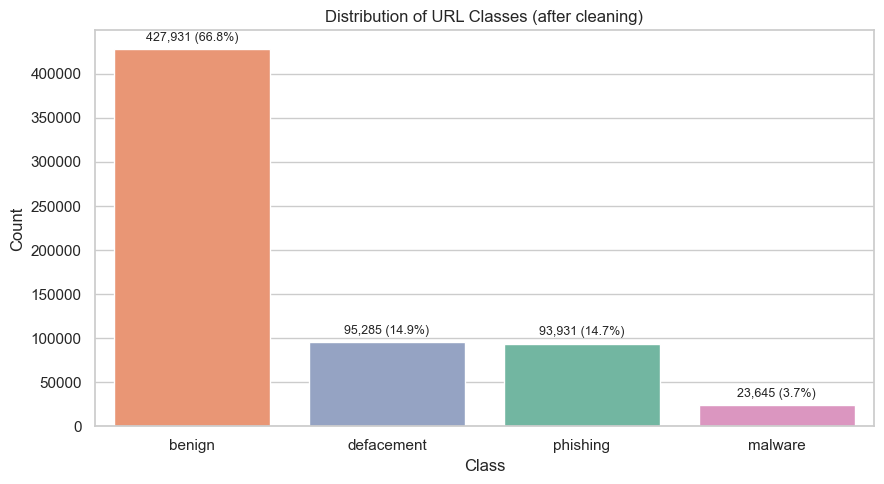

Interpretation: 'benign' remains the majority class (427,931 rows) and 'malware' is the minority class (23,645 rows).


In [106]:
if eda.empty or eda['type'].dropna().empty:
    print('Skipping class distribution chart: no class data available after cleaning.')
else:
    plt.figure(figsize=(9, 5))
    order = eda['type'].value_counts().index
    ax = sns.countplot(data=eda, x='type', order=order, hue='type', palette='Set2', legend=False)
    ax.set_title('Distribution of URL Classes (after cleaning)')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')

    total = len(eda)
    # Add both counts and percentages so the imbalance is visible without manual calculation.
    for patch in ax.patches:
        count = int(patch.get_height())
        pct = 100 * count / total if total else 0
        ax.annotate(
            f"{count:,} ({pct:.1f}%)",
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 4),
            textcoords='offset points',
        )

    finalize_figure()

counts = eda['type'].value_counts()
if counts.empty:
    print('Interpretation unavailable: no class counts available.')
else:
    print(
        f"Interpretation: '{counts.idxmax()}' remains the majority class ({counts.max():,} rows) "
        f"and '{counts.idxmin()}' is the minority class ({counts.min():,} rows)."
    )



### 4.2 URL length behavior
- What this shows: the overall length distribution and the class-level spread of URL lengths.
- Why it matters: the distribution shape determines whether averages or medians are the more reliable summary.
- Insight: right-skew and differing medians suggest malicious classes do not all follow the same lexical pattern.

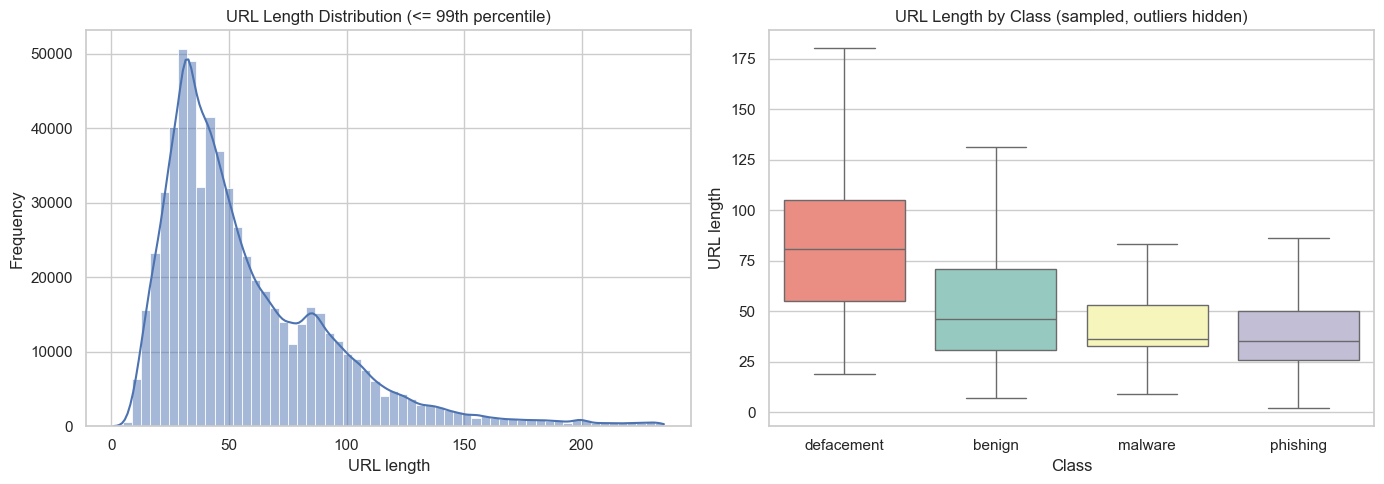

Interpretation: URL length is right-skewed overall. Highest median class = defacement (81), lowest median class = phishing (35).


In [107]:
# Sample large datasets before plotting boxplots so rendering stays responsive.
plot_sample = safe_sample_frame(eda, n=120000, random_state=RANDOM_STATE)
# Clip the histogram at the 99th percentile so extreme outliers do not dominate the x-axis.
upper_cap = eda['url_length'].quantile(0.99) if not eda.empty else np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hist_series = eda.loc[eda['url_length'] <= upper_cap, 'url_length'] if not eda.empty and pd.notna(upper_cap) else pd.Series(dtype='float64')
if hist_series.empty:
    draw_no_data(axes[0], 'URL Length Distribution (<= 99th percentile)')
else:
    sns.histplot(
        hist_series,
        bins=60,
        kde=True,
        ax=axes[0],
        color='#4C72B0',
    )
    axes[0].set_title('URL Length Distribution (<= 99th percentile)')
    axes[0].set_xlabel('URL length')
    axes[0].set_ylabel('Frequency')

if plot_sample.empty or plot_sample['type'].dropna().empty:
    draw_no_data(axes[1], 'URL Length by Class (sampled, outliers hidden)')
else:
    # Order classes by median so the chart reads from longer-typical to shorter-typical URLs.
    order = (
        plot_sample.groupby('type')['url_length']
        .median()
        .sort_values(ascending=False)
        .index
    )
    sns.boxplot(
        data=plot_sample,
        x='type',
        y='url_length',
        hue='type',
        order=order,
        showfliers=False,
        legend=False,
        ax=axes[1],
        palette='Set3',
    )
    axes[1].set_title('URL Length by Class (sampled, outliers hidden)')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('URL length')

finalize_figure(fig)

medians = eda.groupby('type')['url_length'].median().sort_values(ascending=False)
if medians.empty:
    print('Interpretation unavailable: no URL-length medians available.')
else:
    print(
        f"Interpretation: URL length is right-skewed overall. "
        f"Highest median class = {medians.index[0]} ({medians.iloc[0]:.0f}), "
        f"lowest median class = {medians.index[-1]} ({medians.iloc[-1]:.0f})."
    )



### 4.3 Lexical feature patterns
- What this shows: class-wise averages and a correlation view for the core lexical features.
- Why it matters: this helps separate class-specific structure from redundant feature information.
- Insight: stronger positive correlations point to shared structural complexity, not independent signals.

,url_length,digit_count,dot_count,hyphen_count,slash_count
type,,,,,
benign,57.670,5.610,1.940,1.840,2.730
defacement,86.110,4.560,2.840,1.690,3.830
malware,46.610,11.070,3.060,0.350,3.660
phishing,45.730,3.670,2.490,0.470,2.660


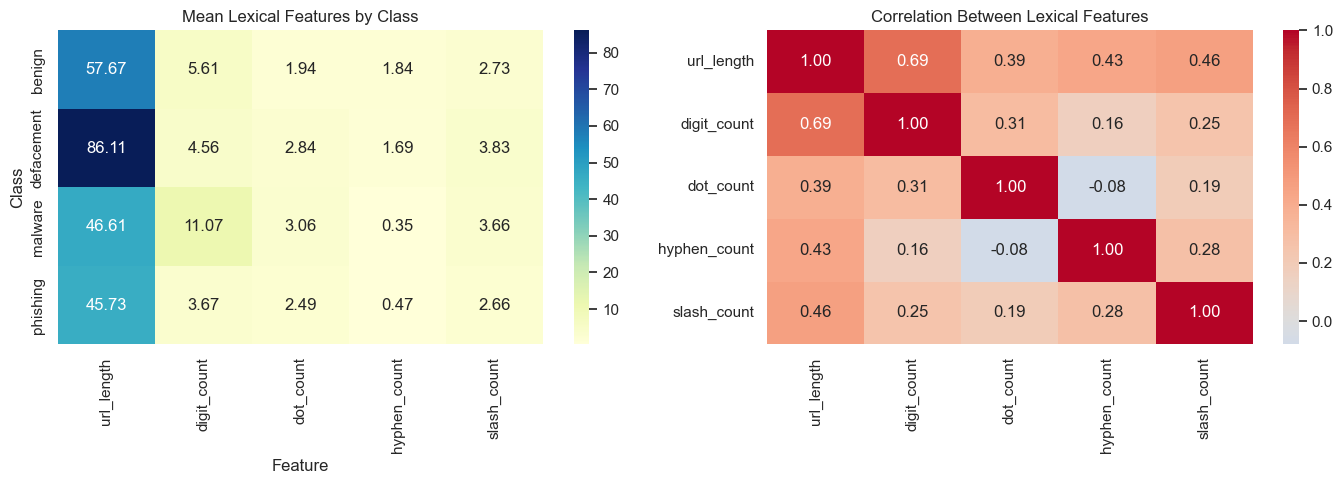

Interpretation: dominant mean lexical feature by class
- benign: url_length (57.67)
- defacement: url_length (86.11)
- malware: url_length (46.61)
- phishing: url_length (45.73)


In [ ]:
numeric_features = ['url_length', 'digit_count', 'dot_count', 'hyphen_count', 'slash_count']

feature_means = (
    eda.groupby('type')[numeric_features]
    .mean()
    .astype(float)
    .round(2)
    .sort_index()
)

display(feature_means)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if feature_means.empty:
    draw_no_data(axes[0], 'Mean Lexical Features by Class')
else:
    sns.heatmap(feature_means, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0])
    axes[0].set_title('Mean Lexical Features by Class')
    axes[0].set_xlabel('Feature')
    axes[0].set_ylabel('Class')

# Correlation helps see which engineered features may be redundant.
corr = eda[numeric_features].astype(float).corr() if not eda.empty else pd.DataFrame()
if corr.empty or corr.isna().all().all():
    draw_no_data(axes[1], 'Correlation Between Lexical Features')
else:
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
    axes[1].set_title('Correlation Between Lexical Features')

finalize_figure(fig)

if feature_means.empty:
    print('Interpretation unavailable: no mean lexical features available by class.')
else:
    top_mean_feature = feature_means.idxmax(axis=1)
    print('Interpretation: dominant mean lexical feature by class')
    for label in feature_means.index:
        feat = top_mean_feature[label]
        print(f"- {label}: {feat} ({feature_means.loc[label, feat]:.2f})")



### 4.4 Statistical reasoning and uncertainty

This subsection makes the notebook's statistical reasoning explicit by pairing point estimates with measures of spread and interval estimates.

- What this shows: descriptive summaries compare central tendency (mean and median), spread (standard deviation and IQR), and uncertainty (95% confidence intervals).
- Why it matters: skewed distributions can make a single average misleading, so robust summaries are needed before drawing conclusions.
- Insight to look for: classes that are both distinct and stable are stronger candidates for interpretable features than classes separated only by extreme outliers.

,n,mean,median,std,q1,q3,iqr,p95,cv,mean_minus_median,mean_ci_low,mean_ci_high
type,,,,,,,,,,,,
defacement,95285,86.110,81.000,41.830,54.000,105.000,51.000,165.000,0.490,5.110,85.840,86.370
benign,427931,57.670,46.000,44.290,31.000,71.000,40.000,125.000,0.770,11.670,57.540,57.800
malware,23645,46.610,37.000,24.950,33.000,53.000,20.000,92.000,0.540,9.610,46.290,46.930
phishing,93931,45.730,35.000,43.480,25.000,49.000,24.000,117.000,0.950,10.730,45.450,46.010


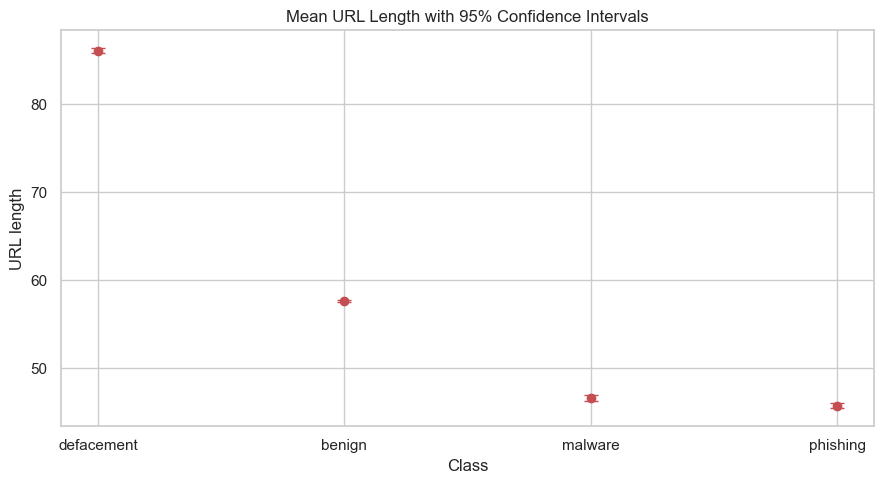

Highest relative variability: phishing (CV=0.95)
Lowest relative variability: defacement (CV=0.49)


In [109]:
length_reasoning = (
    eda.groupby('type')['url_length']
    .agg(
        n='count',
        mean='mean',
        median='median',
        std='std',
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        p95=lambda s: s.quantile(0.95),
    )
)

length_reasoning['iqr'] = length_reasoning['q3'] - length_reasoning['q1']
# Coefficient of variation compares spread relative to the mean.
length_reasoning['cv'] = (length_reasoning['std'] / length_reasoning['mean']).replace([np.inf, -np.inf], np.nan)
length_reasoning['mean_minus_median'] = length_reasoning['mean'] - length_reasoning['median']
# Standard error supports the confidence interval around the mean.
length_reasoning['se'] = length_reasoning['std'] / np.sqrt(length_reasoning['n'])
length_reasoning['mean_ci_low'] = length_reasoning['mean'] - 1.96 * length_reasoning['se']
length_reasoning['mean_ci_high'] = length_reasoning['mean'] + 1.96 * length_reasoning['se']

length_reasoning_display = (
    length_reasoning[
        [
            'n',
            'mean',
            'median',
            'std',
            'q1',
            'q3',
            'iqr',
            'p95',
            'cv',
            'mean_minus_median',
            'mean_ci_low',
            'mean_ci_high',
        ]
    ]
    .round(2)
    .sort_values('mean', ascending=False)
)

display(length_reasoning_display)

fig, ax = plt.subplots(figsize=(9, 5))
if length_reasoning_display.empty:
    draw_no_data(ax, 'Mean URL Length with 95% Confidence Intervals')
else:
    length_reasoning_plot = length_reasoning.reset_index().sort_values('mean', ascending=False)
    valid_ci = length_reasoning_plot[['mean', 'mean_ci_low', 'mean_ci_high']].notna().all(axis=1)
    if not valid_ci.any():
        draw_no_data(ax, 'Mean URL Length with 95% Confidence Intervals', 'Insufficient variance data for confidence intervals.')
    else:
        length_reasoning_plot = length_reasoning_plot.loc[valid_ci].reset_index(drop=True)
        x = np.arange(len(length_reasoning_plot))
        ax.errorbar(
            x,
            length_reasoning_plot['mean'],
            yerr=[
                length_reasoning_plot['mean'] - length_reasoning_plot['mean_ci_low'],
                length_reasoning_plot['mean_ci_high'] - length_reasoning_plot['mean'],
            ],
            fmt='o',
            capsize=5,
            color='#C44E52',
        )
        ax.set_xticks(x)
        ax.set_xticklabels(length_reasoning_plot['type'])
        ax.set_title('Mean URL Length with 95% Confidence Intervals')
        ax.set_xlabel('Class')
        ax.set_ylabel('URL length')

finalize_figure(fig)

valid_cv = length_reasoning['cv'].dropna()
if length_reasoning.empty:
    print('Variability interpretation unavailable: no class-level length statistics available.')
elif valid_cv.empty:
    print('Variability interpretation unavailable: coefficient of variation could not be computed reliably.')
else:
    highest_cv = valid_cv.idxmax()
    lowest_cv = valid_cv.idxmin()
    print(f"Highest relative variability: {highest_cv} (CV={length_reasoning.loc[highest_cv, 'cv']:.2f})")
    print(f"Lowest relative variability: {lowest_cv} (CV={length_reasoning.loc[lowest_cv, 'cv']:.2f})")



- What the statistics show: `defacement` URLs have the highest typical length, while `phishing` has the largest coefficient of variation, indicating the widest relative spread. The repeated gap between mean and median confirms that several classes are right-skewed.
- Why it matters: mean length alone would overstate what a typical URL looks like when long-tail outliers are present, so the median and IQR give a more stable reading.
- Insight: `defacement` appears longer and more consistent, whereas `phishing` and `benign` contain heavier tails. The confidence intervals are narrow because the sample is large, but that precision applies only to this dataset.

,pair,spearman_rho,abs_rho
3,url_length vs slash_count,0.644,0.644
0,url_length vs digit_count,0.563,0.563
2,url_length vs hyphen_count,0.515,0.515
6,digit_count vs slash_count,0.410,0.410
1,url_length vs dot_count,0.351,0.351
9,hyphen_count vs slash_count,0.343,0.343
5,digit_count vs hyphen_count,0.298,0.298
8,dot_count vs slash_count,0.223,0.223
4,digit_count vs dot_count,0.162,0.162
7,dot_count vs hyphen_count,-0.065,0.065


,type,feature,rate_pct,ci_low_pct,ci_high_pct
2,defacement,contains query string,56.620,56.310,56.940
0,benign,contains query string,17.020,16.910,17.130
6,phishing,contains query string,8.700,8.520,8.880
4,malware,contains query string,5.800,5.510,6.100
5,malware,uses IP host,49.770,49.140,50.410
7,phishing,uses IP host,0.350,0.320,0.390
1,benign,uses IP host,0.010,0.000,0.010
3,defacement,uses IP host,0.000,-0.000,0.000


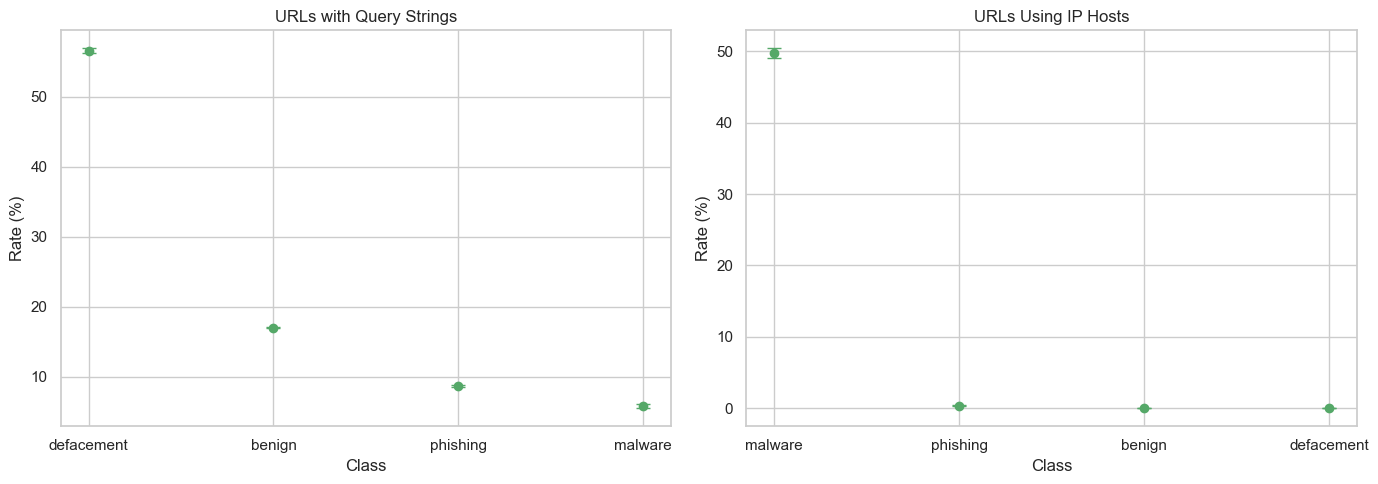

Strongest monotonic association: url_length vs slash_count (Spearman rho=0.644).


In [110]:
# Spearman correlation captures monotonic relationships, not just straight-line ones.
spearman_corr = eda[numeric_features].astype(float).corr(method='spearman') if not eda.empty else pd.DataFrame()

correlation_pairs = []
for i, feature_a in enumerate(spearman_corr.index):
    for j, feature_b in enumerate(spearman_corr.columns):
        if j <= i:
            continue
        rho = spearman_corr.loc[feature_a, feature_b]
        if pd.isna(rho):
            continue
        correlation_pairs.append(
            {
                'pair': f'{feature_a} vs {feature_b}',
                'spearman_rho': rho,
                'abs_rho': abs(rho),
            }
        )

correlation_pairs = pd.DataFrame(correlation_pairs)
if correlation_pairs.empty:
    correlation_pairs_display = pd.DataFrame(columns=['pair', 'spearman_rho', 'abs_rho'])
else:
    correlation_pairs_display = (
        correlation_pairs[['pair', 'spearman_rho', 'abs_rho']]
        .sort_values('abs_rho', ascending=False)
        .round(3)
    )

display(correlation_pairs_display)


def wilson_interval(successes, n, z=1.96):
    # Wilson intervals are more stable than a simple p +/- margin formula near 0 or 1.
    if n == 0:
        return np.nan, np.nan
    p = successes / n
    denom = 1 + (z ** 2) / n
    center = (p + (z ** 2) / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + (z ** 2) / (4 * n)) / n) / denom
    return center - margin, center + margin


feature_label_map = {
    'has_query': 'contains query string',
    'has_ip_host': 'uses IP host',
}

rate_records = []
for label, group in eda.groupby('type'):
    n = len(group)
    for feature in ['has_query', 'has_ip_host']:
        successes = int(group[feature].sum())
        ci_low, ci_high = wilson_interval(successes, n)
        rate_records.append(
            {
                'type': label,
                'feature': feature_label_map[feature],
                'rate_pct': (successes / n) * 100,
                'ci_low_pct': ci_low * 100,
                'ci_high_pct': ci_high * 100,
            }
        )

rate_summary = pd.DataFrame(rate_records)
if rate_summary.empty:
    rate_summary_display = pd.DataFrame(columns=['type', 'feature', 'rate_pct', 'ci_low_pct', 'ci_high_pct'])
else:
    rate_summary_display = rate_summary.sort_values(['feature', 'rate_pct'], ascending=[True, False]).round(2)
display(rate_summary_display)

feature_titles = {
    'contains query string': 'URLs with Query Strings',
    'uses IP host': 'URLs Using IP Hosts',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feature in zip(axes, ['contains query string', 'uses IP host']):
    subset = (
        rate_summary[rate_summary['feature'] == feature]
        .sort_values('rate_pct', ascending=False)
        .reset_index(drop=True)
        if not rate_summary.empty
        else pd.DataFrame()
    )

    if subset.empty:
        draw_no_data(ax, feature_titles[feature])
        continue

    valid_ci = subset[['rate_pct', 'ci_low_pct', 'ci_high_pct']].notna().all(axis=1)
    if not valid_ci.any():
        draw_no_data(ax, feature_titles[feature], 'Confidence intervals unavailable for this subset.')
        continue

    subset = subset.loc[valid_ci].reset_index(drop=True)
    x = np.arange(len(subset))
    ax.errorbar(
        x,
        subset['rate_pct'],
        yerr=[
            subset['rate_pct'] - subset['ci_low_pct'],
            subset['ci_high_pct'] - subset['rate_pct'],
        ],
        fmt='o',
        capsize=5,
        color='#55A868',
    )
    ax.set_xticks(x)
    ax.set_xticklabels(subset['type'])
    ax.set_title(feature_titles[feature])
    ax.set_xlabel('Class')
    ax.set_ylabel('Rate (%)')

finalize_figure(fig)

if correlation_pairs.empty:
    print('Strongest monotonic association unavailable: not enough numeric data.')
else:
    strongest_pair = correlation_pairs.sort_values('abs_rho', ascending=False).iloc[0]
    print(
        f"Strongest monotonic association: {strongest_pair['pair']} "
        f"(Spearman rho={strongest_pair['spearman_rho']:.3f})."
    )



- What these statistics show: longer URLs tend to accumulate more slashes, digits, and hyphens, with `url_length` and `slash_count` showing the strongest monotonic association. The class-level rate intervals show that `defacement` URLs are much more likely to include query strings, while `malware` stands out for IP-based hosts.
- Why it matters: correlated lexical features are not independent, so a later model could end up overweighting the same pattern if features are added without checking redundancy. Confidence intervals make the uncertainty around each rate explicit instead of relying on point estimates alone.
- Insight and limitations: these are descriptive relationships, not causal effects. The intervals are narrow because the dataset is large, but they do not account for label noise, temporal drift, or source-collection bias in the underlying URL feeds.

### 4.5 Suspicious token prevalence
- What this shows: the percentage of URLs in each class that contain common phishing-oriented tokens.
- Why it matters: token frequency is an interpretable signal that can help explain why certain URLs appear risky.
- Insight: token-based cues are useful but incomplete because malicious behavior also appears in URLs without obvious keywords.

,login,verify,account,secure,update,bank
type,,,,,,
benign,3.660,0.080,0.760,0.790,0.630,0.680
defacement,0.330,0.000,0.110,0.000,0.090,0.180
malware,0.210,0.000,0.150,0.310,0.250,0.050
phishing,4.860,1.030,2.280,1.200,1.380,1.180


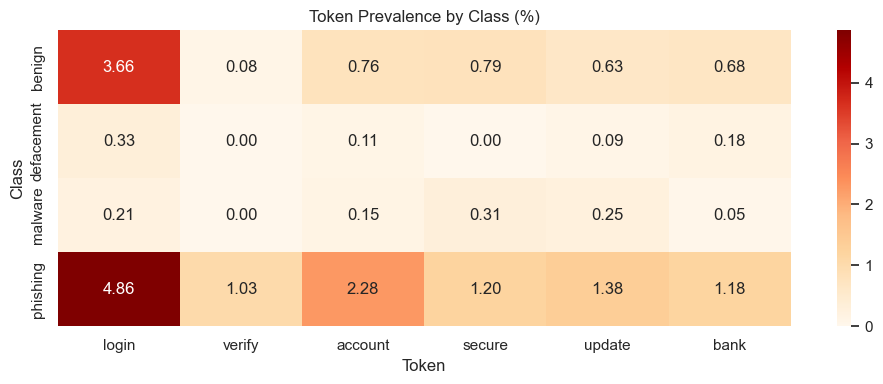

Interpretation: classes with higher rates of account/security tokens are likely to contain more socially engineered URLs.


In [111]:
tokens = ['login', 'verify', 'account', 'secure', 'update', 'bank']
# Build one boolean column per token, then average within each class to get percentages.
token_matrix = pd.DataFrame(
    {
        token: eda['url'].str.contains(fr'(?i){re.escape(token)}', regex=True, na=False)
        for token in tokens
    }
)
token_prevalence = (
    token_matrix.assign(type=eda['type'])
    .groupby('type')[tokens]
    .mean()
    .astype(float)
    .mul(100)
    .round(2)
    .sort_index()
)

display(token_prevalence)

plt.figure(figsize=(10, 4))
if token_prevalence.empty:
    ax = plt.gca()
    draw_no_data(ax, 'Token Prevalence by Class (%)')
else:
    sns.heatmap(token_prevalence.astype(float), annot=True, fmt='.2f', cmap='OrRd')
    plt.title('Token Prevalence by Class (%)')
    plt.xlabel('Token')
    plt.ylabel('Class')

finalize_figure()

if token_prevalence.empty:
    print('Interpretation unavailable: no token prevalence data available.')
else:
    print('Interpretation: classes with higher rates of account/security tokens are likely to contain more socially engineered URLs.')



### 4.6 TLD profile
- What this shows: the within-class composition of the most common top-level domains.
- Why it matters: normalizing within each class separates composition effects from raw class size.
- Insight: TLD differences can reflect attacker preferences, source-collection effects, and registration-policy constraints, so they should be treated as contextual evidence rather than proof of maliciousness.

Interpretation caution:
- Some TLDs are restricted or sponsored and require the registrant to belong to a validated group or institution.
- Examples include `.gov` (U.S. government), `.edu` (accredited post-secondary institutions), `.mil` (U.S. military), `.int` (treaty-based international organizations), and industry-validated spaces such as `.bank`, `.law`, `.insurance`, and `.aero`.
- Country-code TLDs can also have eligibility or local-presence rules, so observed frequencies may reflect jurisdiction and registration policy as much as malicious behavior.
- Because of that, differences in this heatmap should be interpreted as a mix of domain availability, collection bias, and user or attacker choice across different domain ecosystems.



type,benign,defacement,malware,phishing
tld,,,,
au,0.470,4.600,0.300,1.600
br,0.550,7.030,0.660,1.690
ca,2.450,0.550,0.360,0.960
com,78.020,40.940,86.060,63.920
de,0.340,15.130,0.720,1.690
edu,1.750,0.000,0.010,4.060
it,0.180,5.710,0.290,0.840
net,4.790,4.800,2.960,7.070
nl,0.110,8.430,0.440,0.770


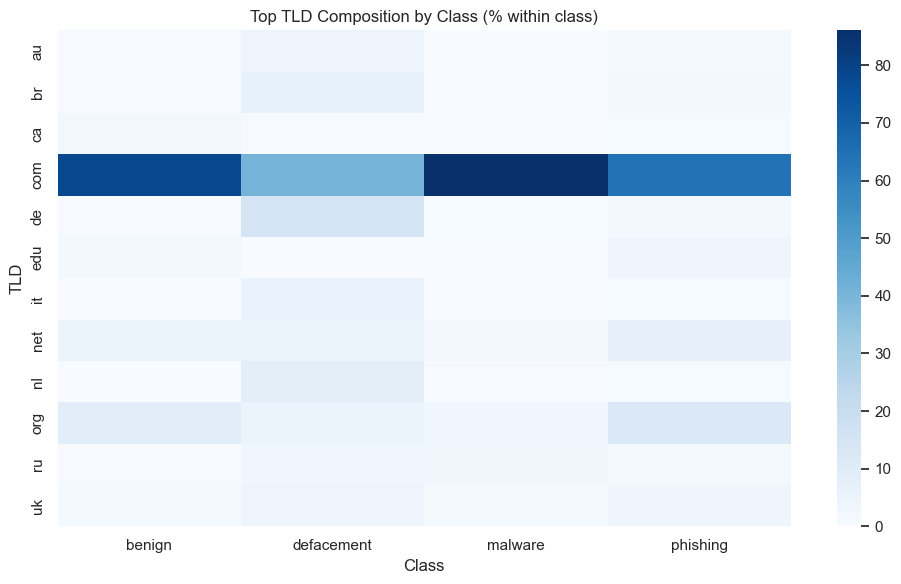

Interpretation: TLD composition differs by class, but those differences should be read carefully. Some domains are restricted or require institutional, professional, or country-specific eligibility, so the observed mix can reflect registration policy and source coverage in addition to attacker or user behavior.


In [112]:
top_tlds = eda['tld'].value_counts().head(12).index
tld_slice = eda[eda['tld'].isin(top_tlds)].copy()

# Normalize by class to compare composition, not raw counts.
tld_profile = (
    pd.crosstab(tld_slice['tld'], tld_slice['type'], normalize='columns')
    .astype(float)
    .mul(100)
    .round(2)
)

display(tld_profile.head(12))

plt.figure(figsize=(10, 6))
if tld_profile.empty:
    ax = plt.gca()
    draw_no_data(ax, 'Top TLD Composition by Class (% within class)')
else:
    sns.heatmap(tld_profile.astype(float), cmap='Blues')
    plt.title('Top TLD Composition by Class (% within class)')
    plt.xlabel('Class')
    plt.ylabel('TLD')

finalize_figure()

if tld_profile.empty:
    print('Interpretation unavailable: no TLD composition data available.')
else:
    print(
        'Interpretation: TLD composition differs by class, but those differences should be read carefully. '
        'Some domains are restricted or require institutional, professional, or country-specific eligibility, '
        'so the observed mix can reflect registration policy and source coverage in addition to attacker or user behavior.'
    )



## Key Takeaways

### Data Acquisition
- Dataset source and upstream origin are documented with a local provenance snapshot (path, size, hash).
- Loading is validated and reproducible through explicit path resolution and schema checks.

### Data Understanding
- Schema and label semantics are defined in a clear data dictionary.
- Class balance, URL length behavior, and scheme usage are quantified before cleaning.

### Data Cleaning
- A deterministic cleaning pipeline removes malformed, duplicate, and label-conflicting records.
- An audit table reports row impact at each step for transparency.

### EDA
- Visualizations cover class imbalance, length distributions, lexical structure, token prevalence, and TLD composition.
- Each chart includes interpretation to connect patterns to malicious URL behavior.

### Statistical Reasoning and Interpretation
- Descriptive summaries combine mean, median, IQR, coefficient of variation, and confidence intervals to distinguish typical behavior from tail effects.
- Relationship analysis uses correlations and class-conditional rate intervals to highlight signal strength, redundancy, and uncertainty.
- Limitations are stated explicitly: within-sample estimates are precise because the dataset is large, but label noise and source bias still constrain generalization.